In [ ]:
#Step 1: Install Libraries
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn xgboost

In [ ]:
# Step 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [ ]:
#Step 3: Load Data
df = pd.read_csv('/content/creditcard.csv')

print("Shape:", df.shape)


Shape: (87240, 31)


In [ ]:
# Step 4: Basic EDA
print(df.info())
print(df.describe())

print("\nClass Distribution:")
print(df['Class'].value_counts(normalize=True)*100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87240 entries, 0 to 87239
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    87240 non-null  int64  
 1   V1      87240 non-null  float64
 2   V2      87240 non-null  float64
 3   V3      87240 non-null  float64
 4   V4      87240 non-null  float64
 5   V5      87239 non-null  float64
 6   V6      87239 non-null  float64
 7   V7      87239 non-null  float64
 8   V8      87239 non-null  float64
 9   V9      87239 non-null  float64
 10  V10     87239 non-null  float64
 11  V11     87239 non-null  float64
 12  V12     87239 non-null  float64
 13  V13     87239 non-null  float64
 14  V14     87239 non-null  float64
 15  V15     87239 non-null  float64
 16  V16     87239 non-null  float64
 17  V17     87239 non-null  float64
 18  V18     87239 non-null  float64
 19  V19     87239 non-null  float64
 20  V20     87239 non-null  float64
 21  V21     87239 non-null  float64
 22

In [ ]:
# Step 5: Train-Test Split (Before Scaling)
# Remove rows with NaN values from the DataFrame before splitting
df_cleaned = df.dropna(subset=['Class'])

X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
def evaluate(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > threshold).astype(int)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))

    return y_prob

In [ ]:
# STEP 6:  FAST HYPERPARAMETER TUNING (RF)
# =========================================

X_sample = X_train.sample(frac=0.2, random_state=42)
y_sample = y_train.loc[X_sample.index]

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

pipeline = Pipeline([

    ('model', rf)
])

param_dist = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [6, 10],
    'model__min_samples_split': [2, 5],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=5,
    scoring='average_precision',# PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1
)

search.fit(X_sample, y_sample)

best_params = search.best_params_
print("\nBest RF Params:", best_params)

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best RF Params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_depth': 6}


In [ ]:
# STEP 7: FINAL RF MODEL (WITH SMOTE)
# =========================================
final_rf = ImbPipeline(steps=[

    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=best_params['model__n_estimators'],
        max_depth=best_params['model__max_depth'],
        min_samples_split=best_params['model__min_samples_split'],
        random_state=42
    ))
])
final_rf.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_depth=6, random_state=42))])

In [ ]:
# STEP 8: EVALUATION FUNCTION
# =========================================
def evaluate(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.5).astype(int)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))

    return y_prob

In [ ]:
# STEP 9: EVALUATE RF
# =========================================
print("\n Random Forest:")
y_prob_rf = evaluate(final_rf, X_test, y_test)


 Random Forest:

Confusion Matrix:
[[17379    28]
 [    2    39]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17407
         1.0       0.58      0.95      0.72        41

    accuracy                           1.00     17448
   macro avg       0.79      0.97      0.86     17448
weighted avg       1.00      1.00      1.00     17448

ROC-AUC: 0.9989098862666688
PR-AUC: 0.8944683921122085


In [ ]:
# STEP 10: RF THRESHOLD TUNING
# =========================================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)
f1_scores = 2*(precision*recall)/(precision+recall+1e-6)
best_threshold_rf = thresholds[np.argmax(f1_scores)]

print("Best RF Threshold:", best_threshold_rf)

Best RF Threshold: 0.7692689134460937


In [ ]:
# STEP 11: LOGISTIC REGRESSION
# =========================================
lr_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

print("\n Logistic Regression:")
y_prob_lr = evaluate(lr_pipeline, X_test, y_test)

In [ ]:
# STEP 12: XGBOOST MODEL (FIXED)
# =========================================
xgb_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=10,
        random_state=42,
        tree_method='hist'  #  fast
    ))
])

xgb_pipeline.fit(X_train, y_train)

print("\n XGBoost:")
y_prob_xgb = evaluate(xgb_pipeline, X_test, y_test)


 XGBoost:

Confusion Matrix:
[[17397    10]
 [    2    39]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17407
         1.0       0.80      0.95      0.87        41

    accuracy                           1.00     17448
   macro avg       0.90      0.98      0.93     17448
weighted avg       1.00      1.00      1.00     17448

ROC-AUC: 0.9995446182990583
PR-AUC: 0.9578470412555267


In [ ]:
# STEP 13: XGB THRESHOLD TUNING
# =========================================
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)
f1_scores_xgb = 2*(precision_xgb*recall_xgb)/(precision_xgb+recall_xgb+1e-6)
best_threshold_xgb = thresholds_xgb[np.argmax(f1_scores_xgb)]

print("Best XGB Threshold:", best_threshold_xgb)


Best XGB Threshold: 0.9989906


In [ ]:
# STEP 14: MODEL COMPARISON
# =========================================
models = {
    "Random Forest": y_prob_rf,
    "Logistic Regression": y_prob_lr,
    "XGBoost": y_prob_xgb
}

results = []

for name, probs in models.items():
    preds = (probs > 0.5).astype(int)

    results.append([
        name,
        roc_auc_score(y_test, probs),
        average_precision_score(y_test, probs),
        f1_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=["Model","ROC-AUC","PR-AUC","F1"])

print("\n Model Comparison:")
print(results_df.sort_values(by="PR-AUC", ascending=False))



 Model Comparison:
                 Model   ROC-AUC    PR-AUC        F1
2              XGBoost  0.999545  0.957847  0.866667
0        Random Forest  0.998910  0.894468  0.722222
1  Logistic Regression  0.990398  0.704027  0.167024


In [ ]:
# STEP 15: BEST MODEL
# =========================================
best_model_name = results_df.sort_values(by="PR-AUC", ascending=False).iloc[0]['Model']
print("\n Best Model:", best_model_name)



 Best Model: XGBoost


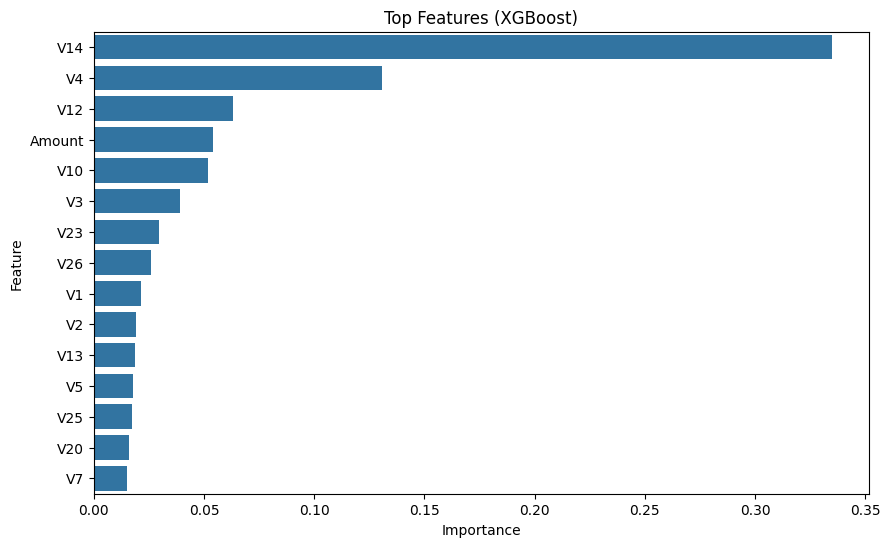

In [ ]:
# STEP 16: FEATURE IMPORTANCE (XGB)
# =========================================
xgb_model = xgb_pipeline.named_steps['model']

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_df.head(15), x="Importance", y="Feature")
plt.title("Top Features (XGBoost)")
plt.show()



In [ ]:
#STEP 17:  FAST CROSS-VALIDATION
# =========================================
from sklearn.model_selection import cross_val_score

X_small = X.sample(frac=0.3, random_state=42)
y_small = y.loc[X_small.index]

xgb_fast = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=150,
        max_depth=6,
        eval_metric='logloss',
        scale_pos_weight=10,
        tree_method='hist',
        random_state=42
    ))
])

cv_score = cross_val_score(
    xgb_fast,
    X_small,
    y_small,
    cv=3,
    scoring='average_precision',
    n_jobs=-1
)

print("\n Fast CV PR-AUC:", cv_score.mean())


 Fast CV PR-AUC: 0.836107749409424
